In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---------- LOAD & CLEAN ----------
df = pd.read_csv(
    "CDC_Influenza.csv",
    encoding="utf-8-sig"
)

# Keep only valid years
df = df[df["Year"].between(2009, 2017)].copy()

# Standardize state names via State Code (handles mixed full-name / abbr + NaNs)
code_to_name = (
    df[df["State"].str.len() > 2]
    .groupby("State Code")["State"]
    .first()
    .to_dict()
)
df["State"] = df["State Code"].map(code_to_name)

# Numeric deaths (Suppressed → NaN)
df["Deaths_num"] = pd.to_numeric(df["Deaths"], errors="coerce")

# Extract month number from Month Code (YYYY/MM)
df["Month_num"] = df["Month Code"].str.split("/").str[1].astype(int)

# Optional: ordered age groups for plotting
age_order = [
    "< 1 year", "1-4 years", "5-14 years", "15-24 years",
    "25-34 years", "35-44 years", "45-54 years", "55-64 years",
    "65-74 years", "75-84 years", "85+ years", "Not Stated"
]
df["Ten-Year Age Groups"] = pd.Categorical(
    df["Ten-Year Age Groups"], categories=age_order, ordered=True
)

print(df.shape)
print(df["State"].nunique(), "states/DC")
print(df.groupby("Year")["Deaths_num"].sum().round(0))

(66079, 10)
51 states/DC
Year
2009    45110.0
2010    42524.0
2011    45889.0
2012    43136.0
2013    49307.0
2014    47669.0
2015    49708.0
2016    43957.0
2017    48119.0
Name: Deaths_num, dtype: float64


   Year  Deaths_num
0  2009     45110.0
1  2010     42524.0
2  2011     45889.0
3  2012     43136.0
4  2013     49307.0
5  2014     47669.0
6  2015     49708.0
7  2016     43957.0
8  2017     48119.0

Top 10 states (total reported deaths 2009-2017):
State
California        54002.0
New York          40875.0
Texas             26759.0
Pennsylvania      22334.0
Florida           22129.0
Illinois          20004.0
Ohio              19042.0
North Carolina    15597.0
Michigan          14270.0
Tennessee         12442.0
Name: Deaths_num, dtype: float64


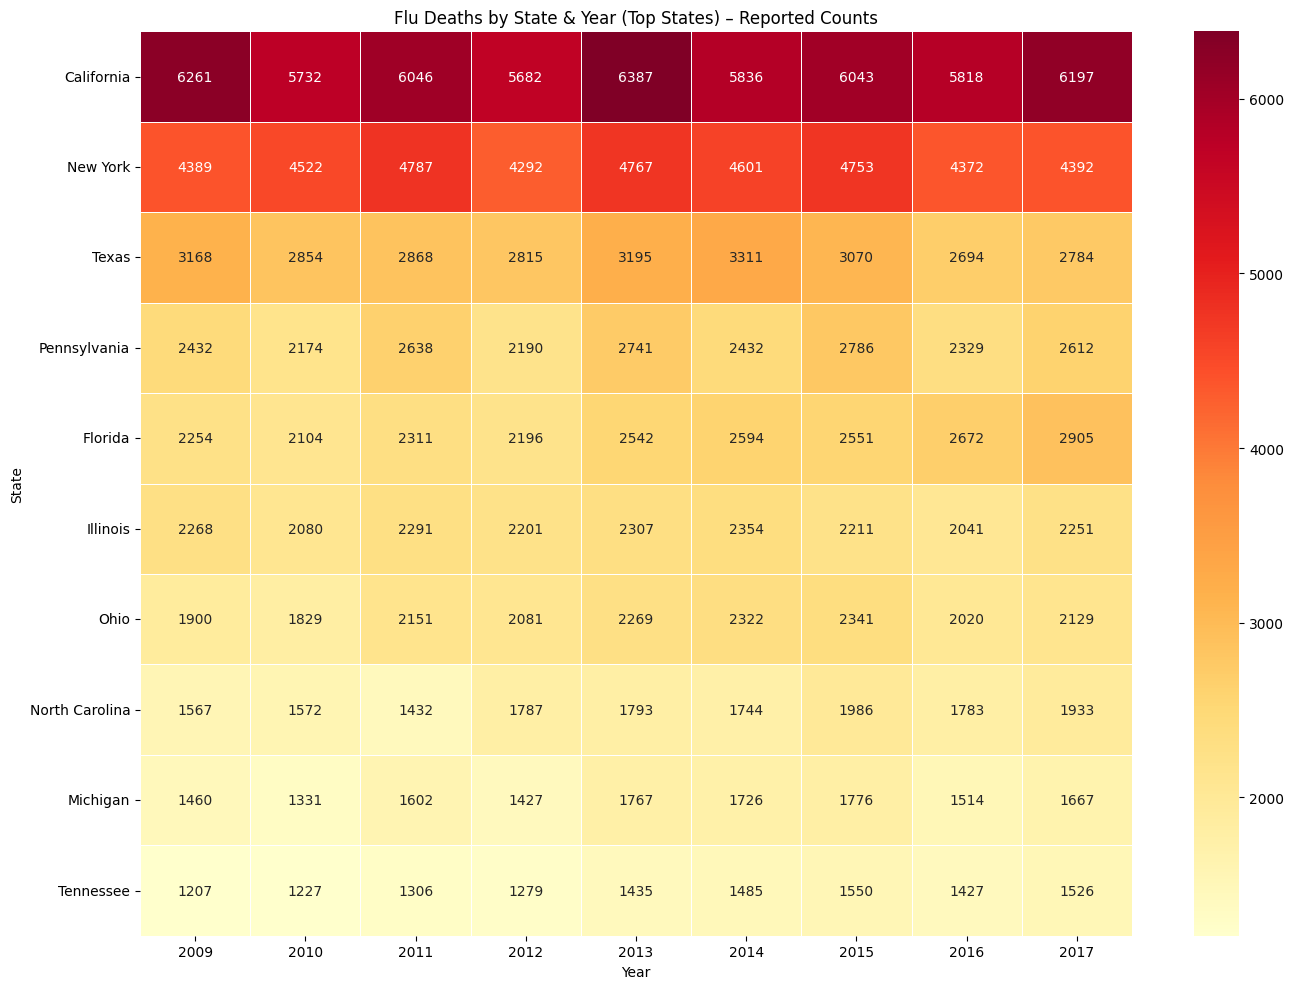

In [2]:
# National annual totals (reported / non-suppressed)
annual = df.groupby("Year")["Deaths_num"].sum().reset_index()
print(annual)

# State × Year totals
state_year = (
    df.groupby(["State", "Year"])["Deaths_num"]
    .sum()
    .unstack(fill_value=0)
    .astype(int)
)

# Top states overall (2009-2017)
top_states = (
    df.groupby("State")["Deaths_num"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 states (total reported deaths 2009-2017):")
print(top_states)

# Heat-map style ranking (for Tableau/Power BI or matplotlib)
plt.figure(figsize=(14, 10))
sns.heatmap(
    state_year.loc[top_states.index],
    annot=True, fmt="d", cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Flu Deaths by State & Year (Top States) – Reported Counts")
plt.tight_layout()
plt.show()

Ten-Year Age Groups
< 1 year            0.0
1-4 years           0.0
5-14 years         10.0
15-24 years        11.0
25-34 years       304.0
35-44 years      1192.0
45-54 years      7779.0
55-64 years     26857.0
65-74 years     53446.0
75-84 years    113081.0
85+ years      212739.0
Not Stated          0.0
Name: Deaths_num, dtype: float64


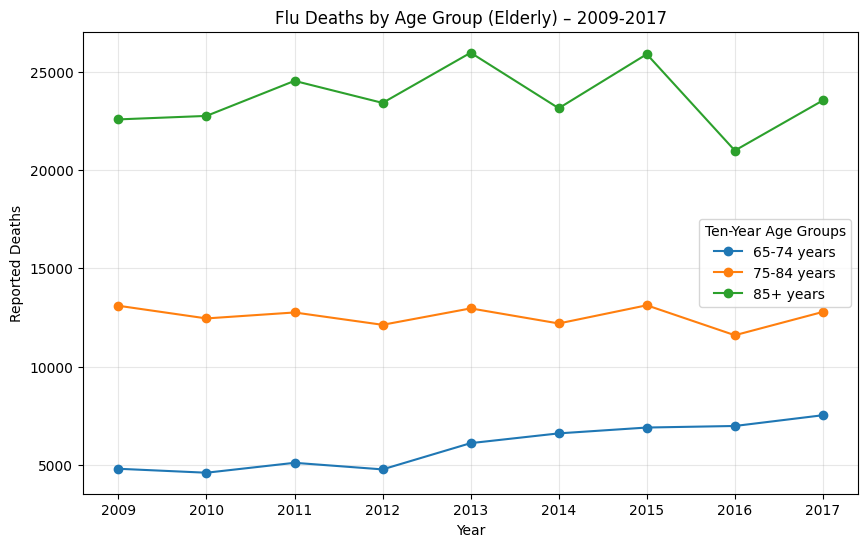


85+ share of reported deaths: 51.2%
65+ share: 91.3%


In [3]:
# Deaths by age group (all years)
age_totals = (
    df.groupby("Ten-Year Age Groups", observed=True)["Deaths_num"]
    .sum()
    .reindex(age_order)
    .dropna()
)

print(age_totals)

# Line chart – deaths by age over years
age_year = (
    df.groupby(["Year", "Ten-Year Age Groups"], observed=True)["Deaths_num"]
    .sum()
    .unstack()
)

# Focus on the three oldest groups (matches the presentation narrative)
elderly_groups = ["65-74 years", "75-84 years", "85+ years"]
age_year[elderly_groups].plot(marker="o", figsize=(10, 6))
plt.title("Flu Deaths by Age Group (Elderly) – 2009-2017")
plt.ylabel("Reported Deaths")
plt.grid(True, alpha=0.3)
plt.show()

# Share of 85+ vs everyone else
total_deaths = df["Deaths_num"].sum()
elderly_85 = df[df["Ten-Year Age Groups"] == "85+ years"]["Deaths_num"].sum()
print(f"\n85+ share of reported deaths: {elderly_85 / total_deaths:.1%}")
print(f"65+ share: {df[df['Ten-Year Age Groups'].isin(elderly_groups)]['Deaths_num'].sum() / total_deaths:.1%}")

Top 10 states – 85+ flu deaths (2009-2017):
State
California        26428.0
New York          20454.0
Pennsylvania      11918.0
Texas             10717.0
Illinois          10101.0
Florida            9784.0
Ohio               8903.0
North Carolina     6981.0
Massachusetts      6925.0
Michigan           6850.0
Name: Deaths_num, dtype: float64


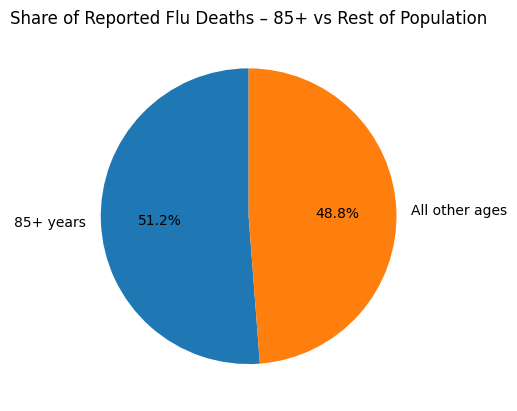

             State  Deaths_85plus
0       California        26428.0
1         New York        20454.0
2     Pennsylvania        11918.0
3            Texas        10717.0
4         Illinois        10101.0
5          Florida         9784.0
6             Ohio         8903.0
7   North Carolina         6981.0
8    Massachusetts         6925.0
9         Michigan         6850.0
10      New Jersey         5633.0
11        Virginia         5341.0
12        Missouri         5277.0
13       Tennessee         5157.0
14       Wisconsin         4882.0


In [4]:
# Elderly (85+) by state
elderly = df[df["Ten-Year Age Groups"] == "85+ years"]
state_elderly = (
    elderly.groupby("State")["Deaths_num"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 states – 85+ flu deaths (2009-2017):")
print(state_elderly.head(10))

# Pie: 85+ vs rest (national)
labels = ["85+ years", "All other ages"]
sizes = [elderly_85, total_deaths - elderly_85]
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Share of Reported Flu Deaths – 85+ vs Rest of Population")
plt.show()

# Treemap-ready table (export to Tableau or use squarify/plotly)
treemap_df = state_elderly.reset_index()
treemap_df.columns = ["State", "Deaths_85plus"]
treemap_df = treemap_df[treemap_df["Deaths_85plus"] > 0]
print(treemap_df.head(15))

Deaths by month number (1=Jan … 12=Dec):
Month_num
1     55802.0
2     43769.0
3     44511.0
4     35516.0
5     30369.0
6     26871.0
7     26017.0
8     24782.0
9     25188.0
10    29784.0
11    30883.0
12    41927.0
Name: Deaths_num, dtype: float64


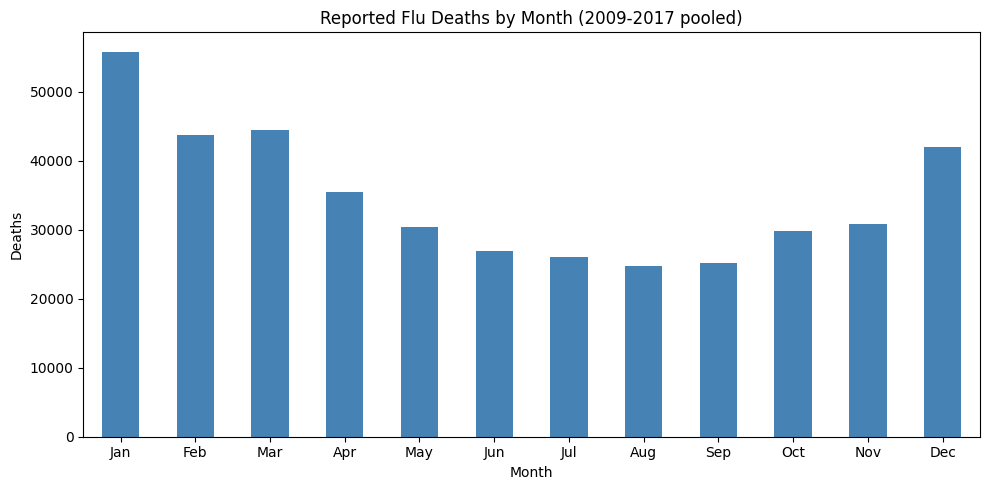


Most common peak month across states:
1     40
2      7
3      3
12     1
Name: count, dtype: int64


In [5]:
# National monthly pattern (all years pooled)
monthly = (
    df.groupby("Month_num")["Deaths_num"]
    .sum()
    .reindex(range(1, 13))
)

print("Deaths by month number (1=Jan … 12=Dec):")
print(monthly)

monthly.plot(kind="bar", color="steelblue", figsize=(10, 5))
plt.title("Reported Flu Deaths by Month (2009-2017 pooled)")
plt.xlabel("Month")
plt.ylabel("Deaths")
plt.xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=0)
plt.tight_layout()
plt.show()

# Peak months by state (example: recent years)
recent = df[df["Year"].isin([2015, 2016, 2017])]
state_month = (
    recent.groupby(["State", "Month_num"])["Deaths_num"]
    .sum()
    .unstack(fill_value=0)
)
# Find peak month per state
peak_month = state_month.idxmax(axis=1)
print("\nMost common peak month across states:")
print(peak_month.value_counts().sort_index())

In [6]:
def top_states_by_year(year: int, n: int = 10):
    return (
        df[df["Year"] == year]
        .groupby("State")["Deaths_num"]
        .sum()
        .sort_values(ascending=False)
        .head(n)
    )

def elderly_share_by_state(year: int = None):
    mask = df["Ten-Year Age Groups"] == "85+ years"
    if year:
        mask &= df["Year"] == year
    elderly = df[mask].groupby("State")["Deaths_num"].sum()
    total = df[df["Year"] == year].groupby("State")["Deaths_num"].sum() if year else df.groupby("State")["Deaths_num"].sum()
    return (elderly / total).sort_values(ascending=False)

# Examples
print(top_states_by_year(2017))
print(elderly_share_by_state(2017).head(10))

State
California        6197.0
New York          4392.0
Florida           2905.0
Texas             2784.0
Pennsylvania      2612.0
Illinois          2251.0
Ohio              2129.0
North Carolina    1933.0
Michigan          1667.0
Tennessee         1526.0
Name: Deaths_num, dtype: float64
State
Rhode Island     1.000000
Wyoming          1.000000
Montana          1.000000
South Dakota     1.000000
Maine            0.907692
Nebraska         0.864198
New Hampshire    0.857143
Hawaii           0.834061
Iowa             0.791768
Minnesota        0.766260
Name: Deaths_num, dtype: float64
